<a href="https://colab.research.google.com/github/Kishoby/Conceptual-Research_Hybrid-Approach/blob/Humidity/XAI_Humidity_VAR.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import numpy as np

from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.tsa.api import VAR

from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# Load your datasets
train_df = pd.read_csv("/content/drive/MyDrive/Research v2/Research 18.03.2026/Humidity/humidity_training_dataset (1).csv")
test_df = pd.read_csv("/content/drive/MyDrive/Research v2/Research 18.03.2026/Humidity/humidity_testing_dataset (1).csv")

target = "humidity"

# Optional: if you have datetime column
# train_df["last_updated"] = pd.to_datetime(train_df["last_updated"])
# test_df["last_updated"] = pd.to_datetime(test_df["last_updated"])

# train_df.set_index("last_updated", inplace=True)
# test_df.set_index("last_updated", inplace=True)

# Evaluation function
def evaluate(y_true, y_pred):
    mse = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    mae = mean_absolute_error(y_true, y_pred)
    r2 = r2_score(y_true, y_pred)

    y_true_safe = np.where(np.array(y_true) == 0, 1e-10, y_true)
    acc = 100 - (np.mean(np.abs((y_true - y_pred) / y_true_safe)) * 100)

    return mse, rmse, mae, r2, acc

In [2]:

var_features = [
    "humidity",
    "temperature_celsius",
    "cloud",
    "precip_mm",
    "visibility_km",
    "air_quality_Ozone"
]

train_var = train_df[var_features].dropna()
test_var = test_df[var_features].dropna()

# =========================
# TRAIN VAR MODEL
# =========================
model = VAR(train_var)
model_fit = model.fit(maxlags=5)

lag_order = model_fit.k_ar

# =========================
# FORECAST
# =========================
forecast = model_fit.forecast(
    train_var.values[-lag_order:],
    steps=len(test_var)
)

forecast_df = pd.DataFrame(
    forecast,
    index=test_var.index,
    columns=var_features
)

# =========================
# EVALUATE (HUMIDITY)
# =========================
metrics_var = evaluate(
    test_var["humidity"],
    forecast_df["humidity"]
)

print("VAR Results (Humidity)")
print(metrics_var)

VAR Results (Humidity)
(560.7211530489766, np.float64(23.67955136925057), 20.612280556744974, -0.1696701977964592, np.float64(60.79816086455021))


In [3]:

results = pd.DataFrame([


    {
        "Model": "VAR",
        "MSE": metrics_var[0],
        "RMSE": metrics_var[1],
        "MAE": metrics_var[2],
        "R2": metrics_var[3],
        "Accuracy (%)": metrics_var[4]
    }
]).round(4)

print(results)

  Model       MSE     RMSE      MAE      R2  Accuracy (%)
0   VAR  560.7212  23.6796  20.6123 -0.1697       60.7982


In [4]:

import pandas as pd

stat_results_table = pd.DataFrame([

    {
        "Model": "VAR",
        "MSE": metrics_var[0],
        "RMSE": metrics_var[1],
        "MAE": metrics_var[2],
        "R2": metrics_var[3],
        "Accuracy (%)": metrics_var[4]
    }
]).round(4)

print(stat_results_table)

  Model       MSE     RMSE      MAE      R2  Accuracy (%)
0   VAR  560.7212  23.6796  20.6123 -0.1697       60.7982


In [5]:
# ============================================================
# Explainable AI / Interpretability for VAR Model - PM2.5
# ============================================================

import os
import zipfile
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from google.colab import files
from statsmodels.graphics.tsaplots import plot_acf
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

save_dir = "/content/VAR_PM25_XAI_Outputs"
os.makedirs(save_dir, exist_ok=True)

In [6]:
# ============================================================
# 1. Fit VAR Model
# ============================================================

var_features = [
   "humidity",
    "temperature_celsius",
    "cloud",
    "precip_mm",
    "visibility_km",
    "air_quality_Ozone"
]

train_var = train_df[var_features].dropna()
test_var = test_df[var_features].dropna()

model = VAR(train_var)

model_fit = model.fit(maxlags=5, ic="aic")

print(model_fit.summary())

  Summary of Regression Results   
Model:                         VAR
Method:                        OLS
Date:           Tue, 07, Jul, 2026
Time:                     04:27:06
--------------------------------------------------------------------
No. of Equations:         6.00000    BIC:                    24.0001
Nobs:                     103997.    HQIC:                   23.9881
Log likelihood:      -2.13228e+06    FPE:                2.60419e+10
AIC:                      23.9830    Det(Omega_mle):     2.59954e+10
--------------------------------------------------------------------
Results for equation humidity
                            coefficient       std. error           t-stat            prob
-----------------------------------------------------------------------------------------
const                         13.476713         0.747366           18.032           0.000
L1.humidity                    0.180648         0.003921           46.073           0.000
L1.temperature_celsiu

In [7]:
# ============================================================
# EXPLAINABILITY FOR BEST STATISTICAL MODEL: VAR - HUMIDITY
# ============================================================

import os
import zipfile
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from google.colab import files
from statsmodels.tsa.api import VAR
from statsmodels.graphics.tsaplots import plot_acf

save_dir = "/content/Humidity_VAR_XAI_Outputs"
os.makedirs(save_dir, exist_ok=True)

target = "humidity"

var_features = [
    "humidity",
    "temperature_celsius",
    "cloud",
    "precip_mm",
    "visibility_km",
    "air_quality_Ozone"
]

In [8]:
# ============================================================
# 1. FIT VAR MODEL
# ============================================================

train_var = train_df[var_features].dropna()
test_var = test_df[var_features].dropna()

var_model = VAR(train_var)
var_fit = var_model.fit(maxlags=5)

print(var_fit.summary())

  Summary of Regression Results   
Model:                         VAR
Method:                        OLS
Date:           Tue, 07, Jul, 2026
Time:                     04:27:30
--------------------------------------------------------------------
No. of Equations:         6.00000    BIC:                    24.0001
Nobs:                     103997.    HQIC:                   23.9881
Log likelihood:      -2.13228e+06    FPE:                2.60419e+10
AIC:                      23.9830    Det(Omega_mle):     2.59954e+10
--------------------------------------------------------------------
Results for equation humidity
                            coefficient       std. error           t-stat            prob
-----------------------------------------------------------------------------------------
const                         13.476713         0.747366           18.032           0.000
L1.humidity                    0.180648         0.003921           46.073           0.000
L1.temperature_celsiu

In [9]:
# ============================================================
# 2. FORECAST HUMIDITY
# ============================================================

lag_order = var_fit.k_ar

forecast = var_fit.forecast(
    train_var.values[-lag_order:],
    steps=len(test_var)
)

forecast_df = pd.DataFrame(
    forecast,
    index=test_var.index,
    columns=var_features
)

y_true = test_var[target].reset_index(drop=True)
y_pred = forecast_df[target].reset_index(drop=True)

residuals = y_true - y_pred
absolute_error = np.abs(residuals)

In [10]:
# ============================================================
# 3. VAR FULL COEFFICIENT TABLE
# ============================================================

var_coef_table = var_fit.params

var_coef_table.to_csv(
    f"{save_dir}/VAR_Humidity_Full_Coefficient_Table.csv"
)

display(var_coef_table)

,humidity,temperature_celsius,cloud,precip_mm,visibility_km,air_quality_Ozone
const,13.476713,7.984146,11.585752,-0.044750,7.065048,45.743675
L1.humidity,0.180648,-0.002332,0.051129,0.000146,0.000363,-0.047850
L1.temperature_celsius,0.058085,0.140381,0.049951,0.001314,0.007009,-0.016179
L1.cloud,-0.016465,0.004208,0.050863,0.000435,-0.000336,0.010742
L1.precip_mm,-0.386091,0.081152,0.570799,0.030023,0.002961,0.041825
L1.visibility_km,0.075946,0.013164,-0.021468,-0.001015,0.026052,-0.101912
L1.air_quality_Ozone,-0.026860,0.001598,-0.016641,-0.000217,-0.001045,0.153704
L2.humidity,0.146593,-0.002472,0.041439,0.000149,0.001760,-0.031486
L2.temperature_celsius,0.041538,0.123371,0.054636,0.001285,0.006557,-0.035619
L2.cloud,-0.008847,0.004467,0.052487,0.000468,-0.000295,0.001044


In [11]:
# ============================================================
# 4. VAR HUMIDITY EQUATION COEFFICIENTS
# ============================================================

humidity_coef = var_coef_table[target].sort_values(
    key=lambda x: np.abs(x),
    ascending=False
)

humidity_coef_df = pd.DataFrame({
    "Variable": humidity_coef.index,
    "Coefficient": humidity_coef.values,
    "Absolute_Coefficient": np.abs(humidity_coef.values)
})

humidity_coef_df.to_csv(
    f"{save_dir}/VAR_Humidity_Equation_Coefficients.csv",
    index=False
)

display(humidity_coef_df)

,Variable,Coefficient,Absolute_Coefficient
0,const,13.476713,13.476713
1,L1.precip_mm,-0.386091,0.386091
2,L2.precip_mm,-0.221146,0.221146
3,L4.visibility_km,0.197806,0.197806
4,L1.humidity,0.180648,0.180648
5,L3.visibility_km,0.172193,0.172193
6,L5.visibility_km,0.170857,0.170857
7,L4.precip_mm,0.156738,0.156738
8,L2.humidity,0.146593,0.146593
9,L3.humidity,0.144355,0.144355


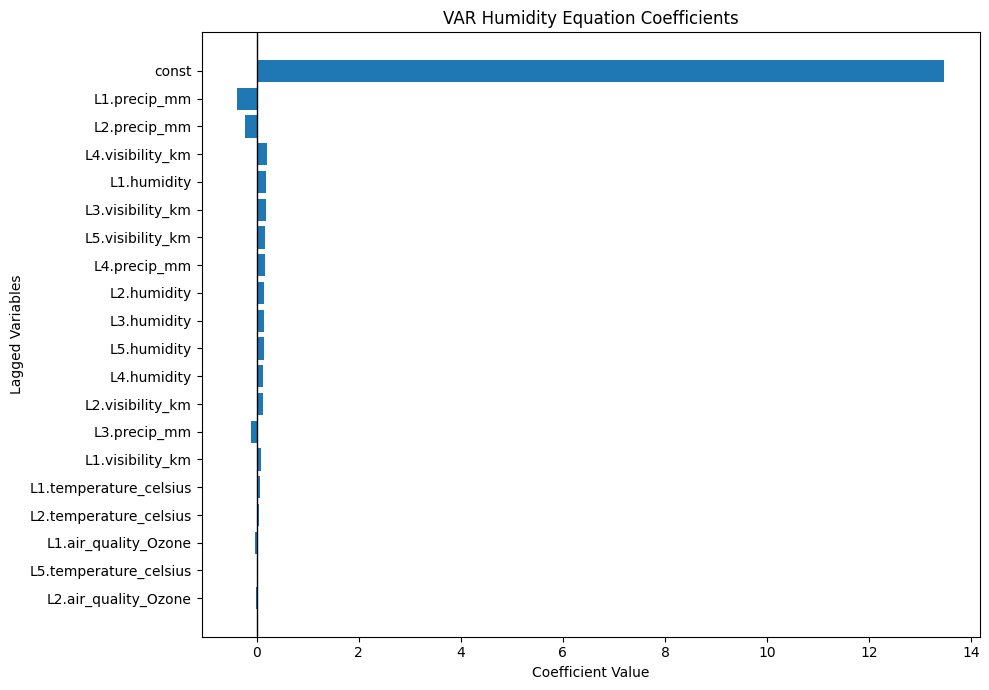

In [12]:
# ============================================================
# 5. VAR COEFFICIENT BAR PLOT
# ============================================================

top_coef = humidity_coef_df.head(20)

plt.figure(figsize=(10,7))

plt.barh(
    top_coef["Variable"][::-1],
    top_coef["Coefficient"][::-1]
)

plt.axvline(0, color="black", linewidth=1)

plt.title("VAR Humidity Equation Coefficients")
plt.xlabel("Coefficient Value")
plt.ylabel("Lagged Variables")
plt.tight_layout()

plt.savefig(
    f"{save_dir}/01_VAR_Humidity_Coefficient_Bar.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()
plt.close()

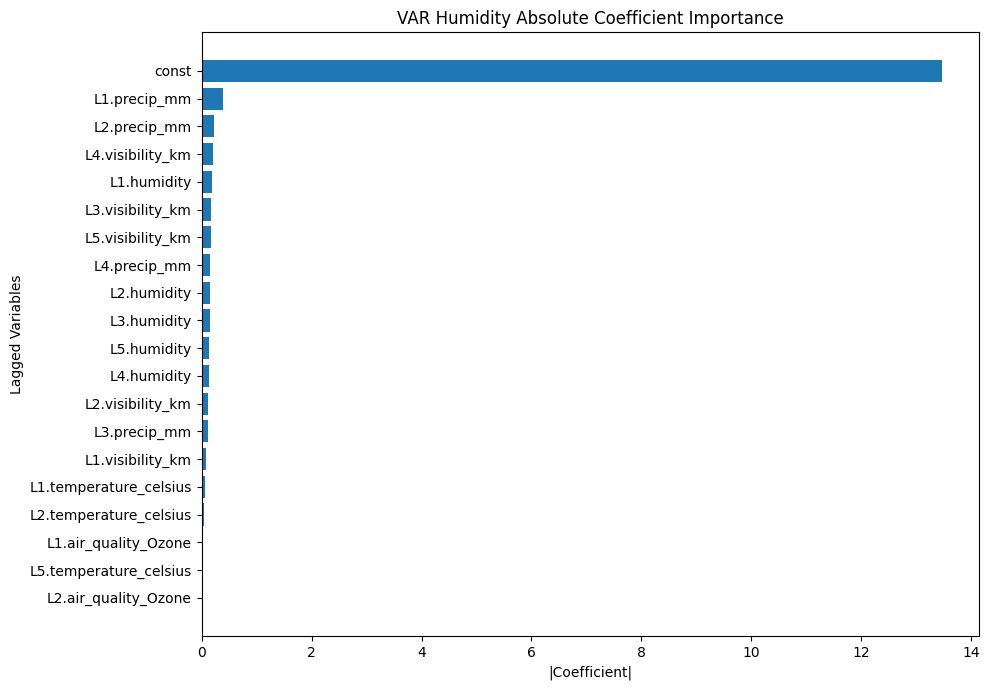

In [13]:
# ============================================================
# 6. VAR ABSOLUTE COEFFICIENT IMPORTANCE
# ============================================================

plt.figure(figsize=(10,7))

plt.barh(
    top_coef["Variable"][::-1],
    top_coef["Absolute_Coefficient"][::-1]
)

plt.title("VAR Humidity Absolute Coefficient Importance")
plt.xlabel("|Coefficient|")
plt.ylabel("Lagged Variables")
plt.tight_layout()

plt.savefig(
    f"{save_dir}/02_VAR_Humidity_Absolute_Coefficient_Importance.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()
plt.close()

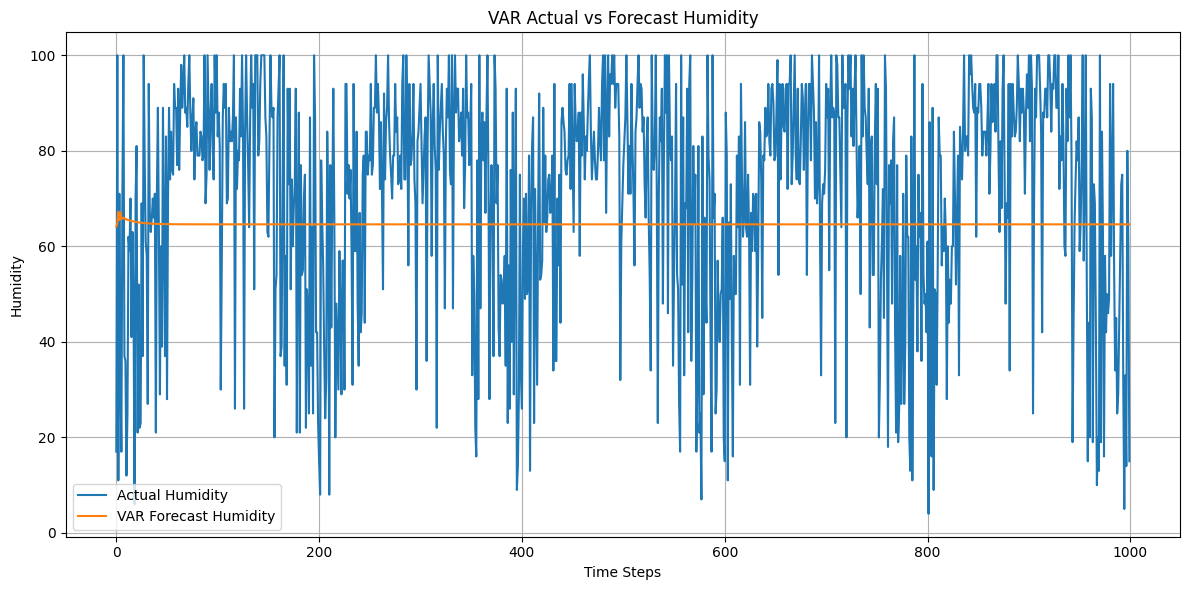

In [14]:
# ============================================================
# 7. ACTUAL VS FORECAST
# ============================================================

plot_n = min(1000, len(y_true))

plt.figure(figsize=(12,6))

plt.plot(y_true[:plot_n], label="Actual Humidity")
plt.plot(y_pred[:plot_n], label="VAR Forecast Humidity")

plt.title("VAR Actual vs Forecast Humidity")
plt.xlabel("Time Steps")
plt.ylabel("Humidity")
plt.legend()
plt.grid(True)
plt.tight_layout()

plt.savefig(
    f"{save_dir}/03_VAR_Actual_vs_Forecast_Humidity.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()
plt.close()

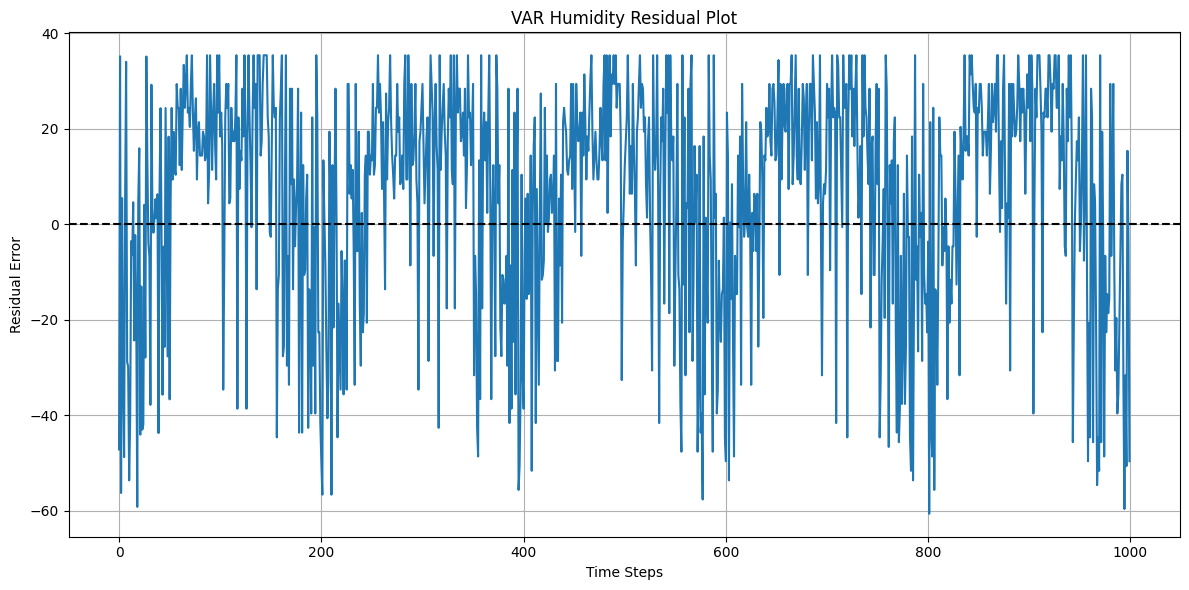

In [15]:
# ============================================================
# 8. RESIDUAL PLOT
# ============================================================

plt.figure(figsize=(12,6))

plt.plot(residuals[:plot_n])
plt.axhline(0, color="black", linestyle="--")

plt.title("VAR Humidity Residual Plot")
plt.xlabel("Time Steps")
plt.ylabel("Residual Error")
plt.grid(True)
plt.tight_layout()

plt.savefig(
    f"{save_dir}/04_VAR_Humidity_Residual_Plot.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()
plt.close()

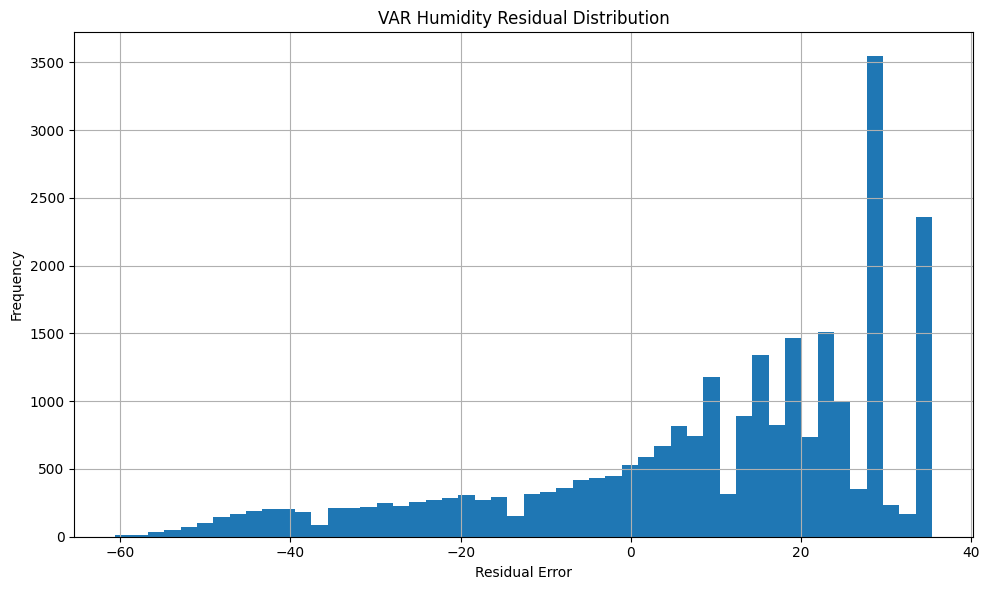

In [16]:
# ============================================================
# 9. RESIDUAL DISTRIBUTION
# ============================================================

plt.figure(figsize=(10,6))

plt.hist(residuals.dropna(), bins=50)

plt.title("VAR Humidity Residual Distribution")
plt.xlabel("Residual Error")
plt.ylabel("Frequency")
plt.grid(True)
plt.tight_layout()

plt.savefig(
    f"{save_dir}/05_VAR_Humidity_Residual_Distribution.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()
plt.close()

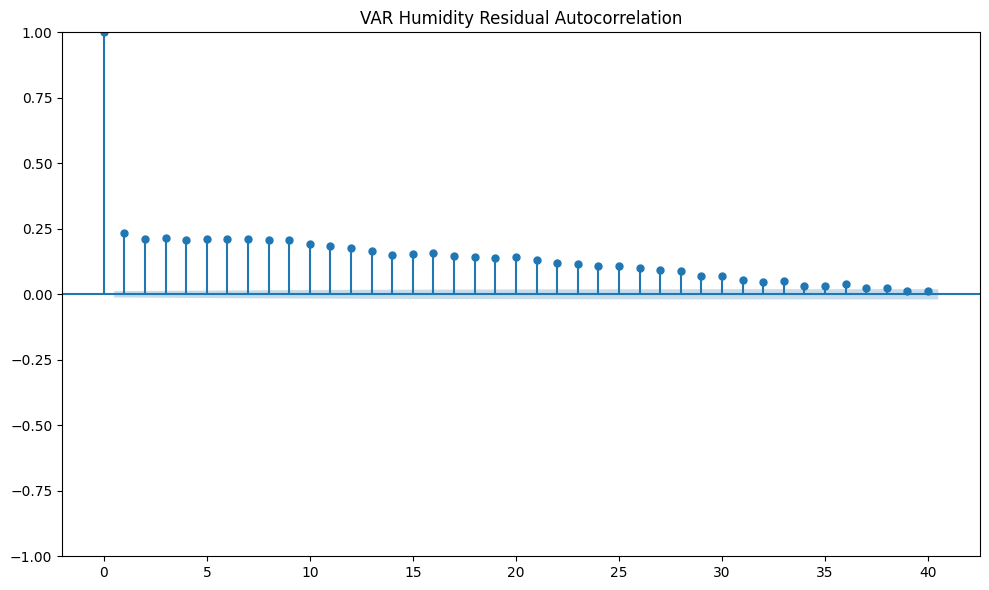

In [17]:
# ============================================================
# 10. RESIDUAL ACF
# ============================================================

fig, ax = plt.subplots(figsize=(10,6))

plot_acf(residuals.dropna(), lags=40, ax=ax)

plt.title("VAR Humidity Residual Autocorrelation")
plt.tight_layout()

plt.savefig(
    f"{save_dir}/06_VAR_Humidity_Residual_ACF.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()
plt.close()

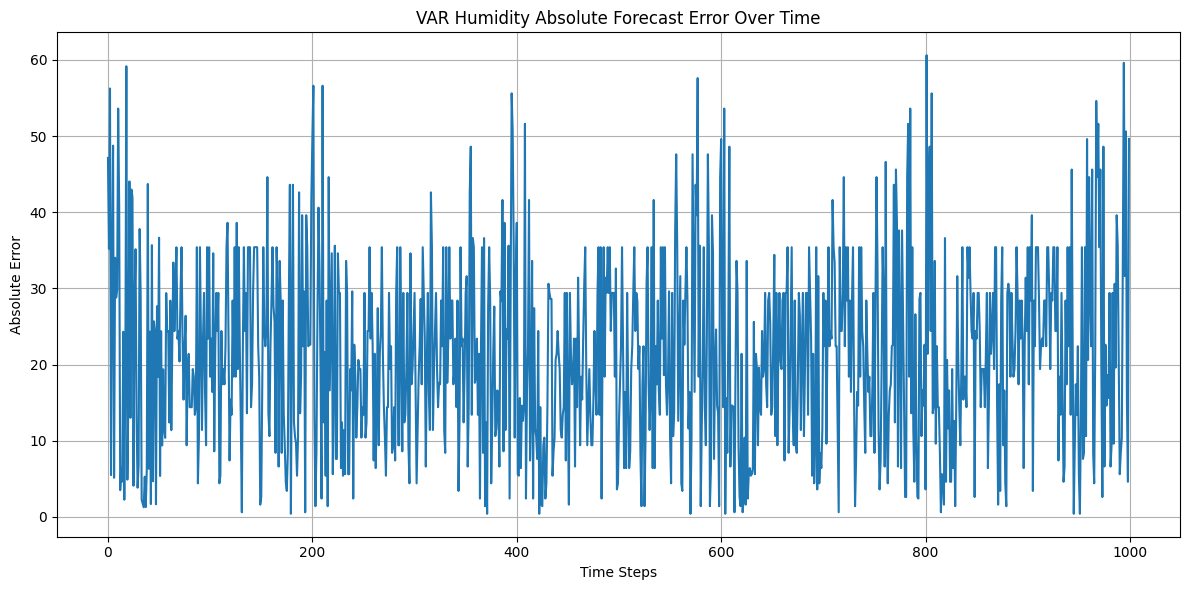

In [18]:
# ============================================================
# 11. ERROR OVER TIME
# ============================================================

plt.figure(figsize=(12,6))

plt.plot(absolute_error[:plot_n])

plt.title("VAR Humidity Absolute Forecast Error Over Time")
plt.xlabel("Time Steps")
plt.ylabel("Absolute Error")
plt.grid(True)
plt.tight_layout()

plt.savefig(
    f"{save_dir}/07_VAR_Humidity_Error_Over_Time.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()
plt.close()

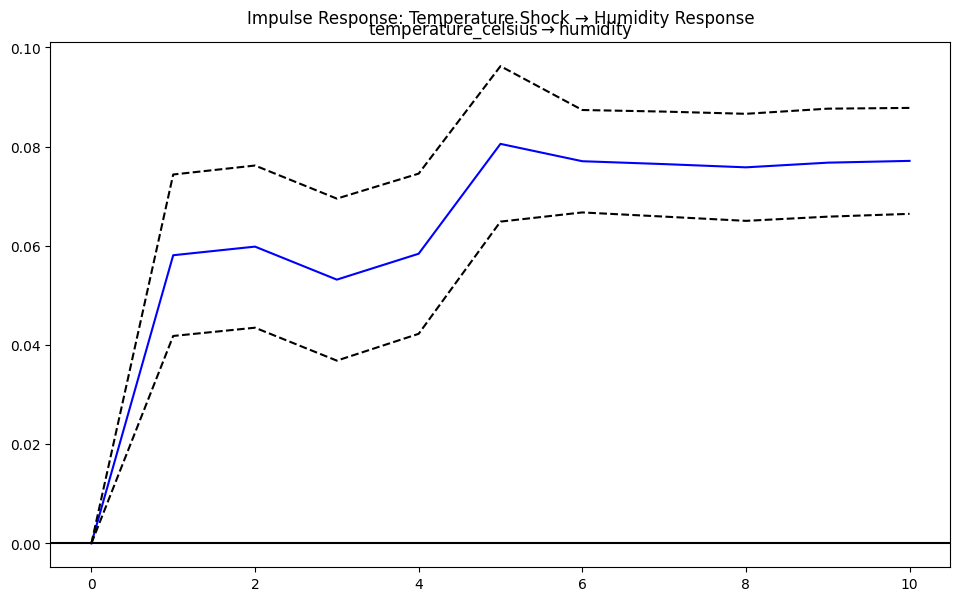

In [19]:
# ============================================================
# 12. IMPULSE RESPONSE FUNCTION
# ============================================================

irf = var_fit.irf(10)

fig = irf.plot(
    impulse="temperature_celsius",
    response="humidity"
)

fig.set_size_inches(10,6)

plt.suptitle("Impulse Response: Temperature Shock → Humidity Response")

plt.savefig(
    f"{save_dir}/08_VAR_IRF_Temperature_to_Humidity.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()
plt.close()

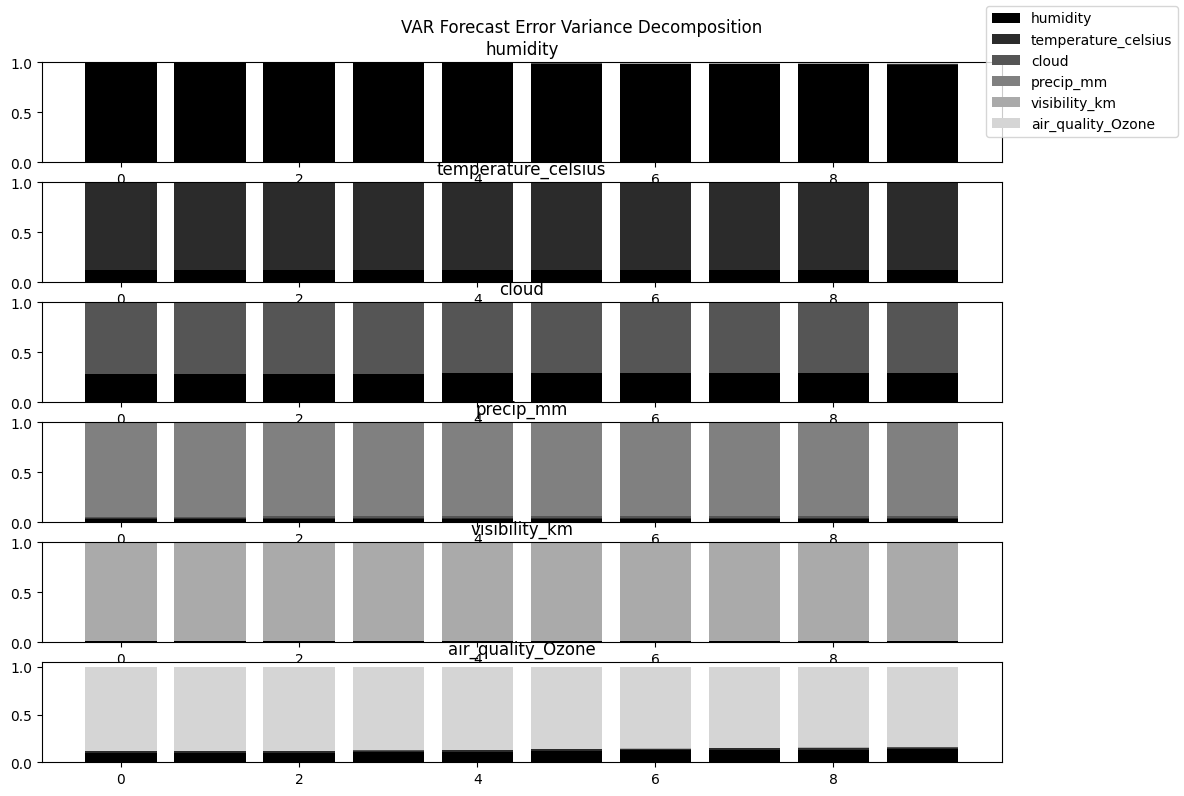

In [20]:
# ============================================================
# 13. FORECAST ERROR VARIANCE DECOMPOSITION
# ============================================================

fevd = var_fit.fevd(10)

fig = fevd.plot()
fig.set_size_inches(12,8)

plt.suptitle("VAR Forecast Error Variance Decomposition")

plt.savefig(
    f"{save_dir}/09_VAR_FEVD_Humidity.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()
plt.close()

In [21]:
# ============================================================
# 14. GRANGER CAUSALITY FOR HUMIDITY
# ============================================================

granger_results = []

for feature in var_features:
    if feature != target:
        try:
            test_result = var_fit.test_causality(
                caused=target,
                causing=[feature],
                kind="f"
            )

            granger_results.append({
                "Causing Variable": feature,
                "Caused Variable": target,
                "Test Statistic": test_result.test_statistic,
                "P-value": test_result.pvalue,
                "Conclusion": "Significant" if test_result.pvalue < 0.05 else "Not Significant"
            })

        except Exception as e:
            granger_results.append({
                "Causing Variable": feature,
                "Caused Variable": target,
                "Test Statistic": np.nan,
                "P-value": np.nan,
                "Conclusion": str(e)
            })

granger_df = pd.DataFrame(granger_results)

granger_df.to_csv(
    f"{save_dir}/VAR_Granger_Causality_Humidity.csv",
    index=False
)

display(granger_df)

,Causing Variable,Caused Variable,Test Statistic,P-value,Conclusion
0,temperature_celsius,humidity,34.242969,4.062678e-35,Significant
1,cloud,humidity,24.808657,4.390695e-25,Significant
2,precip_mm,humidity,4.026209,1.181043e-03,Significant
3,visibility_km,humidity,43.733780,2.918704e-45,Significant
4,air_quality_Ozone,humidity,107.564975,6.106195e-114,Significant


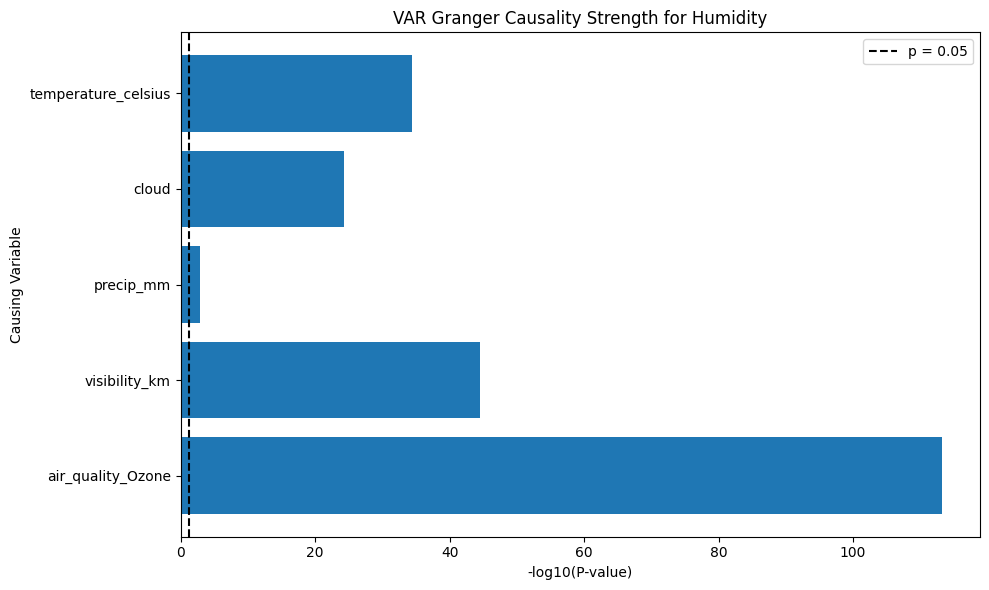

In [22]:
# ============================================================
# 15. GRANGER CAUSALITY PLOT
# ============================================================

granger_plot_df = granger_df.dropna().copy()

granger_plot_df["-log10(P-value)"] = -np.log10(
    granger_plot_df["P-value"]
)

plt.figure(figsize=(10,6))

plt.barh(
    granger_plot_df["Causing Variable"][::-1],
    granger_plot_df["-log10(P-value)"][::-1]
)

plt.axvline(
    -np.log10(0.05),
    color="black",
    linestyle="--",
    label="p = 0.05"
)

plt.title("VAR Granger Causality Strength for Humidity")
plt.xlabel("-log10(P-value)")
plt.ylabel("Causing Variable")
plt.legend()
plt.tight_layout()

plt.savefig(
    f"{save_dir}/10_VAR_Granger_Causality_Humidity.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()
plt.close()

In [23]:
# ============================================================
# 16. ZIP AND DOWNLOAD ALL OUTPUTS
# ============================================================

zip_path = "/content/Humidity_VAR_XAI_Outputs.zip"

with zipfile.ZipFile(zip_path, "w") as zipf:
    for root, dirs, files_list in os.walk(save_dir):
        for file in files_list:
            file_path = os.path.join(root, file)
            zipf.write(file_path, arcname=file)

files.download(zip_path)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>